![Mysql](https://labs.mysql.com/common/logos/mysql-logo.svg)

# Toma de contacto con Jupyter/Colab y SQL (sesión 1)

Esta hoja muestra cómo acceder a bases de datos SQL y también a conectar la salida con Jupyter. Las partes en SQL también se pueden realizar directamente en MySQL ejecutando el programa `mysql` del entorno de ejecución.

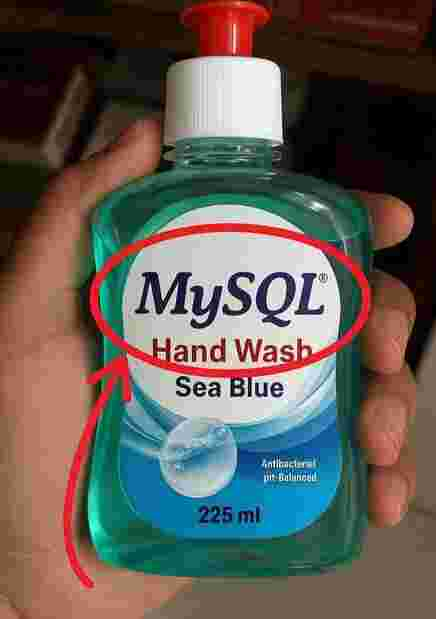



Instalación de los paquetes Python necesarios:

In [ ]:
import sys

RunningInCOLAB: bool = "google.colab" in sys.modules

In [ ]:
if RunningInCOLAB:
    # El runtime de Colab está basado en Ubuntu; instalamos su serie MySQL 8.0.
    !sudo apt-get update -qq
    !sudo DEBIAN_FRONTEND=noninteractive apt-get install -qq -y mysql-server-8.0 mysql-client-8.0
    !sudo service mysql start
    !sudo mysqladmin --protocol=socket ping

    # El servidor es efímero y sólo se usa en esta práctica. PyMySQL soporta
    # caching_sha2_password mediante el paquete cryptography instalado debajo.
    !sudo mysql --protocol=socket -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH caching_sha2_password BY 'root'"
    !mysqladmin --protocol=tcp -h 127.0.0.1 -uroot -proot ping

In [ ]:
%pip install sqlalchemy pymysql cryptography 'pandas[performance,parquet,plot,output-formatting]' 'git+https://github.com/dsevilla/jupysql' fsspec pyarrow requests aiohttp 'jupyter-notebook-slide @ git+https://github.com/dsevilla/jupyter-notebook-slide.git'

In [ ]:
%load_ext notebook_slide

import notebook_slide as ns

# Mantener las etiquetas en español y los colores de las transparencias.
ns.register_slide_type("avance", "A continuación", "#c69200")
ns.register_slide_type("resumen", "Recapitulación", "#287681")
ns.register_slide_type("pregunta", "Pregunta guía", "#a33a2b")
ns.register_slide_type("titulo", "Sección", "#7b2c19", layout="title")
ns.register_alias("diapositiva")

In [ ]:
%%diapositiva avance
# El recorrido de SQL (I)

- Conectar Jupyter/Colab con **MySQL 8** mediante SQLAlchemy y JupySQL
- Leer el esquema remoto de Stack Overflow y crear las tablas con sus restricciones
- Cargar los Parquet por lotes, con transacciones por tabla y comprobaciones controladas
- Explorar datos, claves ajenas, consultas y resultados como `DataFrame`
- Comparar alternativas de modelado y preparar consultas para los ejercicios

> Idea central: el modelo y el plan de acceso importan tanto como la consulta

Cargamos la extensión SQL que permite ejecutar consultas SQL en celdas de Jupyter Notebook y obtener el resultado en un DataFrame de pandas. Esto se puede hacer gracias al paquete `jupysql`.

In [ ]:
%load_ext sql
%config SqlMagic.autopandas=True
%config SqlMagic.displaycon=False
%config SqlMagic.named_parameters="enabled"

In [ ]:
import matplotlib
import pandas as pd
from pandas import DataFrame

%matplotlib inline
matplotlib.style.use("ggplot")

In [ ]:
import os

DB_NAME: str = "stackoverflow"
DB_HOSTNAME: str = os.getenv("DB_HOSTNAME", "127.0.0.1")
DB_USERNAME: str = os.getenv("DB_USERNAME", "root")
DB_PASSWORD: str = os.getenv("DB_PASSWORD", "root")
DB_COLLATION: str = "utf8mb4_0900_as_ci"

Cadena de conexión a la BD:

In [ ]:
from sqlalchemy import URL

SERVER_URL: URL = URL.create(
    "mysql+pymysql",
    username=DB_USERNAME,
    password=DB_PASSWORD,
    host=DB_HOSTNAME,
    query={"charset": "utf8mb4", "collation": DB_COLLATION},
)

In [ ]:
from sqlalchemy import Engine, create_engine, event

admin_engine: Engine = create_engine(SERVER_URL, pool_pre_ping=True)
with admin_engine.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:
    conn.exec_driver_sql(f"DROP DATABASE IF EXISTS `{DB_NAME}`")
    conn.exec_driver_sql(
        f"CREATE DATABASE `{DB_NAME}` CHARACTER SET utf8mb4 COLLATE {DB_COLLATION}"
    )
admin_engine.dispose()

# Las conexiones de trabajo son transaccionales. JupySQL configura sólo la
# conexión que retiene para las celdas SQL en modo AUTOCOMMIT.
engine: Engine = create_engine(
    SERVER_URL.set(database=DB_NAME),
    isolation_level="READ COMMITTED",
    # Cinco cargas en segundo plano y una conexión interactiva de JupySQL.
    # Se evita crear conexiones adicionales de forma ilimitada.
    pool_size=6,
    max_overflow=0,
    pool_pre_ping=True,
)


# El dialecto MySQL de SQLAlchemy ejecuta SET NAMES sólo con el juego de
# caracteres. Este evento se ejecuta después y conserva también la collation
# elegida en cada conexión física que abre el pool, incluidos los loaders.
@event.listens_for(engine, "connect")
def configure_connection_collation(dbapi_connection, _) -> None:
    dbapi_connection.set_character_set("utf8mb4", DB_COLLATION)

La siguiente línea establece la conexión que usarán todas las celdas SQL. Se ha creado antes con los parámetros correctos y con el collation de forma que se distinguen las tildes pero no las mayúsculas y minúsculas.

In [ ]:
%sql engine

In [ ]:
%%sql
-- Aumentamos el espacio disponible para el redo log durante la carga local.
SET GLOBAL innodb_redo_log_capacity = 1000 * 1024 * 1024;

In [ ]:
%%diapositiva avance
# Qué trae el *dump*

- `Users`, `Posts`, `Comments`, `Votes` y `Tags` forman el núcleo del ejemplo
- `Id` identifica cada fila y varias columnas representan referencias
- Los campos opcionales pueden faltar o llegar como `null`
- El esquema será la base del DDL, las consultas y las cargas posteriores

> Antes de insertar, leamos qué significan las columnas y sus relaciones

<details><summary><b>🗂️ Formato de los datos de Stack Overflow</b> <span style="color: #007acc;">▶️ Haz clic para ver el esquema completo</span></summary>

La descripción siguiente resume la [documentación vigente del *data dump* y de SEDE](https://meta.stackexchange.com/questions/2677/database-schema-documentation-for-the-public-data-dump-and-sede/2678). Las prácticas utilizan el *dump* de Stack Overflow en español; SEDE contiene además tablas que no se distribuyen en esos ocho ficheros XML.

> **Notas generales**
>
> - Cada fichero contiene elementos `<row ... />` codificados en UTF-8 y se distribuye dentro de un archivo 7z.
> - Los campos opcionales cuyo valor es nulo no aparecen como atributos en el XML. En los Parquet de la asignatura se representan normalmente como `null`.
> - Las fechas están en UTC y suelen usar el formato `YYYY-MM-DDTHH:mm:ss.fff`.
> - `Id` identifica la fila; los campos indicados como FK hacen referencia al `Id` de otra tabla.

---

:file_folder: <b>Badges.xml</b> — insignias concedidas a usuarios

- `Id`: clave primaria de la concesión.
- `UserId`: usuario que recibe la insignia; FK a `Users.Id`.
- `Name`: nombre de la insignia.
- `Date`: fecha de concesión.
- `Class`: clase de insignia (`1` = oro, `2` = plata, `3` = bronce).
- `TagBased`: `True` si está asociada a una etiqueta; `False` si es una insignia con nombre propio.

---

:file_folder: <b>Comments.xml</b> — comentarios en publicaciones

- `Id`: clave primaria.
- `PostId`: publicación comentada; FK a `Posts.Id`.
- `Score`: puntuación del comentario.
- `Text`: cuerpo del comentario.
- `CreationDate`: fecha de creación.
- `UserDisplayName`: nombre visible del autor cuando no puede referenciarse mediante `UserId`.
- `UserId`: autor; FK opcional a `Users.Id`, ausente si el usuario fue eliminado.
- `ContentLicense`: licencia Creative Commons del contenido.

---

:file_folder: <b>Posts.xml</b> — publicaciones no eliminadas

- `Id`: clave primaria.
- `PostTypeId`: tipo de publicación:
  - `1` pregunta; `2` respuesta; `3` wiki de etiqueta huérfana; `4` extracto de wiki de etiqueta; `5` wiki de etiqueta.
  - `6` candidatura a moderación; `7` marcador wiki; `8` wiki de privilegio; `9` artículo; `10` artículo de ayuda.
  - `12` colección; `13` respuesta a cuestionario de moderación; `14` anuncio; `15` discusión de colectivo; `17` colección de colectivo.
- `AcceptedAnswerId`: respuesta aceptada; FK opcional a `Posts.Id`, sólo para preguntas.
- `ParentId`: pregunta a la que responde; FK a `Posts.Id`, sólo para respuestas.
- `CreationDate`: fecha de creación.
- `Score`: puntuación neta.
- `ViewCount`: número de visitas, opcional.
- `Body`: cuerpo ya renderizado como HTML, no Markdown.
- `OwnerUserId`: autor; FK opcional a `Users.Id`. No aparece si se eliminó el usuario y vale `-1` en las entradas de wiki de etiqueta.
- `OwnerDisplayName`: nombre del autor cuando no hay un usuario referenciable.
- `LastEditorUserId`: último editor; FK opcional a `Users.Id`.
- `LastEditorDisplayName`: nombre del último editor cuando no hay un usuario referenciable.
- `LastEditDate`: fecha de la edición más reciente, opcional.
- `LastActivityDate`: fecha de la actividad más reciente.
- `Title`: título de la pregunta o, en determinados posts de tipo `4`/`5`, nombre de la etiqueta.
- `Tags`: etiquetas de la pregunta o etiqueta asociada a determinados posts de tipo `4`/`5`.
- `AnswerCount`: número de respuestas no eliminadas; sólo aparece en preguntas.
- `CommentCount`: número de comentarios, opcional.
- `FavoriteCount`: número histórico de favoritos, opcional.
- `ClosedDate`: fecha de cierre, sólo si la publicación está cerrada.
- `CommunityOwnedDate`: fecha desde la que la publicación es *community wiki*, si corresponde.
- `ContentLicense`: licencia Creative Commons del contenido.

Desde el *dump* de julio de 2025, `Posts.xml` incluye dos publicaciones artificiales con los identificadores `1000000001` y `1000000010`; no existen en SEDE y pueden excluirse. `DeletionDate` pertenece a `PostsWithDeleted` en SEDE y **no** aparece en el *data dump*.

---

:file_folder: <b>PostHistory.xml</b> — historial de las publicaciones

- `Id`: clave primaria del evento.
- `PostHistoryTypeId`: tipo de evento:
  - `1` título inicial; `2` cuerpo inicial; `3` etiquetas iniciales.
  - `4` edición de título; `5` edición de cuerpo; `6` edición de etiquetas.
  - `7`, `8`, `9`: reversión de título, cuerpo o etiquetas.
  - `10` cierre; `11` reapertura; `12` eliminación; `13` restauración; `14` bloqueo; `15` desbloqueo; `16` pasa a *community wiki*.
  - `17` migración antigua (sustituida por `35`/`36`); `18` fusión; `19` protección; `20` desprotección; `21` desasociación del autor; `22` deshacer fusión.
  - `24` edición sugerida aplicada; `25` publicación tuiteada; `31` discusión de comentarios movida al chat.
  - `33` aviso añadido; `34` aviso retirado; `35` migrada a otro sitio; `36` migrada desde otro sitio; `37` origen de fusión; `38` destino de fusión.
  - `50` subida por el usuario Community; `52` entrada en Hot Network Questions; `53` retirada de HNQ por moderación; `66` creada mediante el asistente de preguntas.
- `PostId`: publicación afectada; FK a `Posts.Id`.
- `RevisionGUID`: agrupa los registros producidos por una misma revisión.
- `CreationDate`: fecha del evento.
- `UserId`: usuario que realizó el cambio; FK opcional a `Users.Id`.
- `UserDisplayName`: nombre visible si el usuario fue eliminado o si se trata del autor de una publicación migrada.
- `Comment`: comentario de edición; para el tipo `10` contiene el motivo de cierre y para `33`/`34`, el identificador del aviso.
- `Text`: valor nuevo en crudo. En ciertos eventos de moderación contiene JSON con los votantes; en duplicados incluye `OriginalQuestionIds`, y para el tipo `17` contiene los detalles de migración.
- `ContentLicense`: licencia Creative Commons del contenido.

---

:file_folder: <b>PostLinks.xml</b> — enlaces entre publicaciones

- `Id`: clave primaria.
- `CreationDate`: fecha de creación del enlace.
- `PostId`: publicación origen; FK a `Posts.Id`.
- `RelatedPostId`: publicación relacionada o destino; FK a `Posts.Id`.
- `LinkTypeId`: tipo de enlace (`1` = enlazada, `3` = duplicada).

---

:file_folder: <b>Users.xml</b> — usuarios

- `Id`: clave primaria.
- `Reputation`: reputación.
- `CreationDate`: fecha de alta.
- `DisplayName`: nombre visible.
- `LastAccessDate`: última carga de una página por el usuario; se actualiza como máximo cada 30 minutos.
- `WebsiteUrl`: sitio web, opcional.
- `Location`: ubicación declarada, opcional.
- `AboutMe`: presentación del perfil, opcional.
- `Views`: visitas al perfil.
- `UpVotes`: votos positivos emitidos.
- `DownVotes`: votos negativos emitidos.
- `ProfileImageUrl`: URL de la imagen de perfil, opcional.
- `EmailHash`: actualmente siempre es nulo y, por tanto, no aparece en el XML.
- `AccountId`: identificador del perfil de red de Stack Exchange; opcional si el usuario oculta esa comunidad en su perfil.

El antiguo campo `Age` ya no forma parte del esquema documentado.

---

:file_folder: <b>Votes.xml</b> — votos y otras acciones sobre publicaciones

- `Id`: clave primaria.
- `PostId`: publicación afectada; FK a `Posts.Id`.
- `VoteTypeId`: tipo de voto o acción:
  - `-1` informar a moderación; `0` deshacer voto de moderación; `1` aceptación por el autor; `2` voto positivo; `3` voto negativo; `4` ofensivo.
  - `5` favorito/marcador (función retirada en octubre de 2022); `6` cierre (desde 2013 se guarda sólo en `PostHistory`); `7` reapertura.
  - `8` inicio de recompensa; `9` fin de recompensa; `10` eliminación; `11` restauración; `12` spam.
  - `15` revisión de moderación; `16` aprobación de edición sugerida; `17`–`21` reacciones/seguimiento; `22`–`28` reacciones de Teams.
  - `29` obsoleta; `30` no obsoleta; `31` voto previo; `32` voto positivo y `33` voto negativo en discusión de colectivo; `35`–`37` evaluación privada de respuesta de IA.
- `UserId`: usuario; sólo está presente para los tipos `5` y `8` (`-1` si se eliminó).
- `CreationDate`: fecha del voto. Por privacidad, la hora se elimina.
- `BountyAmount`: importe de la recompensa; sólo para los tipos `8` y `9`.

No todos los tipos enumerados pueden aparecer en SEDE o en el *dump* público; algunos son exclusivos de Teams o de experimentos concretos.

---

:file_folder: <b>Tags.xml</b> — etiquetas

- `Id`: clave primaria.
- `TagName`: nombre de la etiqueta.
- `Count`: número de preguntas que la usan.
- `ExcerptPostId`: publicación con el extracto de la wiki; FK opcional a `Posts.Id`.
- `WikiPostId`: publicación con el texto de la wiki; FK opcional a `Posts.Id`.
- `IsModeratorOnly`: indica si sólo moderación puede usarla.
- `IsRequired`: indica si su uso es obligatorio.

---

### Diagrama entidad-relación de SEDE

![Diagrama entidad-relación de Stack Exchange Data Explorer](https://raw.githubusercontent.com/dsevilla/bdge/26-27/docs/img/stackexchange-sede-erd.png)

El diagrama corresponde a **SEDE**, cuyo esquema es más rico que los ocho ficheros del *data dump*. Se incluye como visión global de tablas y relaciones; no implica que todas esas tablas estén disponibles en los Parquet de las prácticas. Fuente y autoría: [“The Schema Visualized”](https://meta.stackexchange.com/a/326361).

</details>

Definimos una función para leer el esquema de cada conjunto de datos. Lo describimos anteriormente como un esquema PyArrow.


In [ ]:
import fsspec
import pyarrow as pa
import pyarrow.parquet as pq
from fsspec.parquet import open_parquet_file


def read_remote_parquet_schema(url: str) -> pa.Schema:
    """Lee el esquema Arrow haciendo peticiones HTTP sólo al footer Parquet."""
    with open_parquet_file(url, engine="pyarrow", footer_sample_size=1_000_000) as parquet_file:
        return pq.read_schema(parquet_file)

In [ ]:
from asyncio import gather, to_thread

PARQUET_BASE_URL: str = (
    "https://github.com/dsevilla/bd2-data/releases/download/es.stackoverflow.data-26-27"
)
PARQUET_NAMES: tuple[str, ...] = ("Posts", "Users", "Tags", "Comments", "Votes")

posts_schema: pa.Schema
users_schema: pa.Schema
tags_schema: pa.Schema
comments_schema: pa.Schema
votes_schema: pa.Schema

posts_schema, users_schema, tags_schema, comments_schema, votes_schema = await gather(
    *(
        to_thread(read_remote_parquet_schema, f"{PARQUET_BASE_URL}/{name}.parquet")
        for name in PARQUET_NAMES
    )
)

In [ ]:
def gen_create_table_from_schema(schema: pa.Schema, table_name: str) -> str:
    """Genera DDL MySQL a partir de tipos y metadatos del esquema Arrow."""
    type_mapping: dict[pa.DataType, str] = {
        pa.int8(): "TINYINT",
        pa.int16(): "SMALLINT",
        pa.int32(): "INTEGER",
        pa.int64(): "BIGINT",
        pa.uint8(): "TINYINT UNSIGNED",
        pa.uint16(): "SMALLINT UNSIGNED",
        pa.uint32(): "INTEGER UNSIGNED",
        pa.uint64(): "BIGINT UNSIGNED",
        pa.float32(): "FLOAT",
        pa.float64(): "DOUBLE",
        pa.bool_(): "BOOLEAN",
        pa.string(): "TEXT",
        pa.large_string(): "TEXT",
        pa.binary(): "BLOB",
        pa.large_binary(): "BLOB",
    }

    def get_sql_type(arrow_type: pa.DataType) -> str:
        if pa.types.is_dictionary(arrow_type):
            return get_sql_type(arrow_type.value_type)
        if pa.types.is_timestamp(arrow_type):
            precision = {"s": 0, "ms": 3, "us": 6, "ns": 6}[arrow_type.unit]
            return "DATETIME" if precision == 0 else f"DATETIME({precision})"
        if pa.types.is_date(arrow_type):
            return "DATE"
        if pa.types.is_time(arrow_type):
            precision = 6 if arrow_type.unit in ("us", "ns") else 0
            return "TIME" if precision == 0 else f"TIME({precision})"
        if pa.types.is_decimal(arrow_type):
            return f"DECIMAL({arrow_type.precision},{arrow_type.scale})"
        try:
            return type_mapping[arrow_type]
        except KeyError as exc:
            raise TypeError(f"Tipo Arrow no soportado en MySQL: {arrow_type}") from exc

    columns: list[str] = []
    primary_keys: list[str] = []
    foreign_keys: list[str] = []

    for field in schema:
        metadata: dict[str, str] = {
            key.decode("utf-8"): value.decode("utf-8")
            for key, value in (field.metadata or {}).items()
        }
        null_constraint = "" if field.nullable else " NOT NULL"
        columns.append(f"`{field.name}` {get_sql_type(field.type)}{null_constraint}")

        role = metadata.get("role")
        if role == "primary_key":
            primary_keys.append(field.name)
        elif role == "foreign_key":
            try:
                referenced_table, referenced_column = metadata["references"].split(".", maxsplit=1)
            except (KeyError, ValueError) as exc:
                raise ValueError(f"Referencia inválida en {table_name}.{field.name}") from exc
            foreign_keys.append(
                f"FOREIGN KEY (`{field.name}`) REFERENCES "
                f"`{referenced_table}` (`{referenced_column}`)"
            )
        elif role is not None:
            raise ValueError(f"Rol desconocido en {table_name}.{field.name}: {role}")

    definitions = columns.copy()
    if primary_keys:
        pk_columns = ", ".join(f"`{name}`" for name in primary_keys)
        definitions.append(f"PRIMARY KEY ({pk_columns})")
    definitions.extend(foreign_keys)

    body = ",\n    ".join(definitions)
    return (
        f"CREATE TABLE `{table_name}` (\n    {body}\n) "
        f"ENGINE=InnoDB DEFAULT CHARACTER SET utf8mb4 COLLATE {DB_COLLATION};"
    )

In [ ]:
%%diapositiva avance
# Importar un esquema y sus datos

- Consultar sólo el *footer* de cada Parquet para conocer columnas y metadatos
- Generar el `CREATE TABLE` de MySQL, incluidas claves primarias y ajenas
- Crear todas las tablas antes de cargar y reservar una conexión por tarea
- Cargar `Users` primero y dejar el resto en segundo plano

> Mientras se cargan los datos, observaremos qué garantías ofrece realmente cada conexión

## Importación de los datos

Las tablas se crean con sus claves ajenas, pero durante la carga cada tarea desactiva `foreign_key_checks` **sólo en su propia sesión**. La tarea conserva una conexión y una transacción para todos los lotes de una tabla: los `INSERT` multivalor no hacen un `COMMIT` individual y, si falla un lote, se revierte la tabla completa.

La conexión interactiva de JupySQL es distinta y mantiene las comprobaciones activadas. Al terminar, cada tarea vuelve a activar `foreign_key_checks` antes de devolver su conexión al *pool*. Activar de nuevo la variable no comprueba retrospectivamente los datos importados; más adelante buscaremos explícitamente referencias huérfanas.

El *pool* del `Engine` está limitado a seis conexiones: una para JupySQL y una por cada uno de los cinco cargadores. `max_overflow=0` hace visible si se intenta superar ese límite, en lugar de abrir conexiones adicionales sin control.

Primero creamos todas las tablas a partir de sus esquemas. Después iniciamos la carga de `Users` y, a continuación, la de las demás tablas en tareas de segundo plano. Así podemos consultar los usuarios mientras continúan las cargas independientes.

In [ ]:
import sys
from asyncio import Task, create_task, to_thread
from queue import Queue


def parquet_to_sql(
    engine: Engine,
    tablename: str,
    parquet_file: str,
    logqueue: Queue[str] | None = None,
    batch_size: int = 20_000,
) -> None:
    """Carga una tabla Parquet en una sola conexión y transacción MySQL."""

    if logqueue is not None:

        def log(message: str) -> None:
            logqueue.put_nowait(message)

    else:

        def log(message: str) -> None: ...

    url: str = f"{PARQUET_BASE_URL}/{parquet_file}"
    try:
        with fsspec.open(url, "rb") as parquet_stream, engine.connect() as conn:
            parquet: pq.ParquetFile = pq.ParquetFile(parquet_stream)
            names: list[str] = parquet.schema_arrow.names
            quote = conn.dialect.identifier_preparer.quote
            insert_sql: str = (
                f"INSERT INTO {quote(tablename)} "
                f"({', '.join(quote(name) for name in names)}) "
                f"VALUES ({', '.join(['%s'] * len(names))})"
            )
            raw_connection = conn.connection.driver_connection

            # SET inicia el autobegin de SQLAlchemy; lo confirmamos antes de
            # abrir explícitamente la única transacción de carga de la tabla.
            conn.exec_driver_sql("SET SESSION foreign_key_checks = 0")
            conn.commit()
            try:
                with conn.begin(), raw_connection.cursor() as cursor:
                    for record_batch in parquet.iter_batches(
                        batch_size=batch_size, use_threads=True
                    ):
                        values: list[list[object]] = [
                            column.to_pylist() for column in record_batch.columns
                        ]
                        log(f"{tablename}: enviando un lote de {record_batch.num_rows:,} filas")
                        inserted: int = cursor.executemany(insert_sql, zip(*values))
                        log(f"{tablename}: filas insertadas por PyMySQL: {inserted}")
            finally:
                # El bloque begin() ya ha confirmado o revertido la carga. Si
                # esta restauración falla mientras se propaga un error de
                # carga, no debe sustituir esa excepción original.
                loading_failed: bool = sys.exc_info()[1] is not None
                try:
                    conn.exec_driver_sql("SET SESSION foreign_key_checks = 1")
                    conn.commit()
                except Exception as cleanup_exc:
                    log(f"{tablename}: no se pudo restaurar foreign_key_checks: {cleanup_exc!r}")
                    if not loading_failed:
                        raise
    except Exception as exc:
        log(f"Error durante la carga de {tablename}: {exc!r}")
        raise

In [ ]:
users_schema_sql: str = gen_create_table_from_schema(users_schema, "Users")

print(users_schema_sql)

In [ ]:
%%sql
{{users_schema_sql}}

In [ ]:
posts_schema_sql: str = gen_create_table_from_schema(posts_schema, "Posts")

print(posts_schema_sql)

In [ ]:
%%sql
{{posts_schema_sql}}

In [ ]:
tags_schema_sql: str = gen_create_table_from_schema(tags_schema, "Tags")

print(tags_schema_sql)

In [ ]:
%%sql
{{tags_schema_sql}}

In [ ]:
comments_schema_sql: str = gen_create_table_from_schema(comments_schema, "Comments")

print(comments_schema_sql)

In [ ]:
%%sql
{{comments_schema_sql}}

In [ ]:
votes_schema_sql: str = gen_create_table_from_schema(votes_schema, "Votes")

print(votes_schema_sql)

In [ ]:
%%sql
{{votes_schema_sql}}

In [ ]:
users_log_queue: Queue = Queue()
users_dataframe_task: Task[None] = create_task(
    to_thread(parquet_to_sql, engine, "Users", "Users.parquet", users_log_queue)
)

In [ ]:
# Esperar a que termine la tarea de Users. Después cargaremos el resto de tablas en segundo plano en paralelo
await users_dataframe_task
while not users_log_queue.empty():
    print(users_log_queue.get_nowait())

In [ ]:
posts_log_queue: Queue = Queue()
posts_dataframe_task: Task[None] = create_task(
    to_thread(
        parquet_to_sql,
        engine,
        "Posts",
        "Posts.parquet",
        posts_log_queue,
    )
)

In [ ]:
tags_log_queue: Queue = Queue()
tags_dataframe_task: Task[None] = create_task(
    to_thread(parquet_to_sql, engine, "Tags", "Tags.parquet", tags_log_queue)
)

In [ ]:
comments_log_queue: Queue = Queue()
comments_dataframe_task: Task[None] = create_task(
    to_thread(parquet_to_sql, engine, "Comments", "Comments.parquet", comments_log_queue)
)

In [ ]:
votes_log_queue: Queue = Queue()
votes_dataframe_task: Task[None] = create_task(
    to_thread(parquet_to_sql, engine, "Votes", "Votes.parquet", votes_log_queue)
)

In [ ]:
%%sql
DESCRIBE Users;

In [ ]:
%%sql
SELECT * FROM Users LIMIT 3;

In [ ]:
await tags_dataframe_task
while not tags_log_queue.empty():
    print(tags_log_queue.get_nowait())

In [ ]:
%%sql
select * from Tags limit 6;

In [ ]:
await posts_dataframe_task
while not posts_log_queue.empty():
    print(posts_log_queue.get_nowait())

In [ ]:
%%sql
select count(*) from Posts;

In [ ]:
%%sql
select * from Posts LIMIT 3;

In [ ]:
%%sql
DESCRIBE Posts;

In [ ]:
await comments_dataframe_task
while not comments_log_queue.empty():
    print(comments_log_queue.get_nowait())

In [ ]:
%%sql
SELECT COUNT(*) FROM Comments;

In [ ]:
%%sql
SELECT * FROM Comments LIMIT 3;

In [ ]:
await votes_dataframe_task
while not votes_log_queue.empty():
    print(votes_log_queue.get_nowait())

In [ ]:
%%sql
select * from Votes LIMIT 20;

Podemos ver con un `LEFT JOIN` que hay `PostId` de los votos que no tienen correspondencia en `Posts`. Esto es normal: los votos de tipo `6` (cierre) y `7` (reapertura) se guardan en `PostHistory` y no en `Posts`. Sin embargo, para evitar inconsistencias con las claves ajenas, eliminaremos esos votos después.

A continuación vemos diferentes planes que realiza el optimizador. Se incluyen para saber interpretar los resultados de `EXPLAIN` y `EXPLAIN ANALYZE`.

In [ ]:
%%sql
EXPLAIN
SELECT Y.PostId,Y.Present
FROM (SELECT v.PostId AS PostId, COALESCE(p.Id,CONCAT('No: ', v.PostId)) AS Present
      FROM Votes v LEFT JOIN Posts p ON v.PostId = p.Id) AS Y
WHERE Y.Present LIKE 'No%';

In [ ]:
%%sql
EXPLAIN ANALYZE
SELECT Y.PostId,Y.Present
FROM (SELECT v.PostId AS PostId, COALESCE(p.Id,CONCAT('No: ', v.PostId)) AS Present
      FROM Votes v LEFT JOIN Posts p ON v.PostId = p.Id) AS Y
WHERE Y.Present LIKE 'No%';

O equivalenemente:

In [ ]:
%%sql
EXPLAIN ANALYZE
SELECT v.PostId AS PostId, COALESCE(p.Id,CONCAT('No: ', v.PostId)) AS Present
FROM Votes v LEFT JOIN Posts p ON v.PostId = p.Id
WHERE COALESCE(p.Id,CONCAT('No: ', v.PostId)) LIKE 'No%'; -- Se tiene que usar la misma condición

In [ ]:
%%sql
EXPLAIN SELECT PostId from Votes WHERE PostId NOT IN (select Id from Posts);

Equivalentemente, como `p.Id` será `NULL` para los votos que se refieran a publicaciones que no existen, podemos escribirla así:

In [ ]:
%%sql

SELECT v.Id,
       v.PostId,
       CONCAT('No: ', v.PostId) AS Present
FROM Votes AS v
LEFT JOIN Posts AS p ON p.Id = v.PostId
WHERE p.Id IS NULL
LIMIT 100;

### EJERCICIO 1: Eliminar de `Votes` las entradas que se refieran a Posts inexistentes

Recuerda confirmar el borrado (con `engine.begin()`, o `COMMIT` si usas `%%sql`): la comprobación siguiente abre otra conexión y sólo ve lo que ya está confirmado.

In [ ]:
# Comprobación del EJERCICIO 1: no debe quedar ningún voto que apunte a un Post inexistente
from sqlalchemy import text

# Lo decide la misma consulta que encontraba los votos huérfanos: si el borrado se ha hecho,
# ya no devuelve ninguna fila. pandas abre otra conexión del pool: sólo ve lo confirmado con COMMIT.
sin_post: pd.DataFrame = pd.read_sql(
    text(
        "SELECT v.Id, v.PostId FROM Votes AS v "
        "WHERE NOT EXISTS (SELECT 1 FROM Posts AS p WHERE p.Id = v.PostId) LIMIT 10"
    ),
    engine,
)
conteo: pd.DataFrame = pd.read_sql(text("SELECT COUNT(*) AS Votos FROM Votes"), engine)
votos: int = int(conteo["Votos"].iloc[0])

print(f"Votos que quedan en Votes: {votos:,}")
print(f"Votos que siguen sin Post (muestra de hasta 10): {len(sin_post)}")
print(sin_post.to_string(index=False))
assert votos > 0, "Se han borrado también los votos que sí apuntan a un Post existente"
assert sin_post.empty, "Quedan votos cuyo PostId no existe en Posts (¿falta el COMMIT?)"
print("EJERCICIO 1: comprobado")

Cada cargador ha vuelto a activar las comprobaciones en su sesión antes de devolver la conexión al *pool*. La conexión retenida por JupySQL nunca las desactivó. Comprobamos su estado; recuerda que esto no valida retrospectivamente las filas cargadas.

In [ ]:
%%sql
-- Las claves ajenas ya formaban parte del CREATE TABLE.
SHOW CREATE TABLE Votes;

In [ ]:
%%sql
SHOW TABLES;

In [ ]:
%%diapositiva resumen
# Qué ha dejado la carga

- Todas las tablas se han creado a partir del esquema de Parquet
- Cada tarea ha cargado sus lotes en una transacción independiente
- Las comprobaciones de claves ajenas vuelven a estar activas en cada conexión
- Podemos consultar SQL y reutilizar sus resultados desde Python

> La base ya está lista: ahora veremos qué preguntas podemos hacerle

In [ ]:
%%diapositiva avance
# Consultar y visualizar

- Usar `LEFT JOIN` para conservar filas sin correspondencia
- Comparar `NOT IN`, `NOT EXISTS` y el plan que produce MySQL
- Llevar una consulta a un `DataFrame` y representarla con Pandas
- Preparar preguntas sobre respuestas, etiquetas y usuarios

> La misma evidencia sirve para razonar en SQL y en Python

In [ ]:
top_tags: DataFrame = get_ipython().run_line_magic(
    "sql", "SELECT Id, TagName, Count FROM Tags ORDER BY Count DESC LIMIT 40;"
)

¡¡Los resultados de `%sql` son un `DataFrame`!!

In [ ]:
top_tags

In [ ]:
# invert_y_axis() hace que el más usado aparezca primero. Por defecto es al revés.
top_tags.plot(kind="barh", x="TagName", y="Count", figsize=(14, 14 * 2 / 3)).invert_yaxis()

In [ ]:
%%sql
select Id,TagName,Count from Tags WHERE Count > 5 ORDER BY Count ASC LIMIT 40;

### EJERCICIO 2: Calcular las preguntas con más respuestas

En la casilla siguiente, obtén las 10 preguntas (`PostTypeId = 1`) con mayor `AnswerCount`, mostrando `Id`, `Title` y `AnswerCount`, de mayor a menor (si hay empates en `AnswerCount`, desempata por `Id` ascendente). Guarda el resultado en la variable `resultado_2` (con `%%sql resultado_2 <<`).

In [ ]:
# Comprobación del EJERCICIO 2: las 10 preguntas con más respuestas
from sqlalchemy import text

assert "resultado_2" in globals(), "Guarda el resultado en la variable resultado_2"
assert {"Id", "Title", "AnswerCount"} <= set(resultado_2.columns), "Faltan Id, Title o AnswerCount"

# Una lectura de columnas estrechas de Posts se reutiliza en los ejercicios 2, 6, 10 y 12.
posts_referencia: pd.DataFrame = pd.read_sql(
    text(
        "SELECT Id, PostTypeId, ParentId, OwnerUserId, AcceptedAnswerId, AnswerCount, Score "
        "FROM Posts"
    ),
    engine,
)
preguntas_referencia: pd.DataFrame = posts_referencia.loc[
    posts_referencia["PostTypeId"] == 1, ["Id", "AnswerCount"]
]
esperado: list[int] = preguntas_referencia["AnswerCount"].nlargest(10).tolist()
obtenido: list[int] = resultado_2["AnswerCount"].tolist()
son_preguntas: int = int(resultado_2["Id"].isin(preguntas_referencia["Id"]).sum())

print(f"AnswerCount esperados: {esperado}")
print(f"AnswerCount obtenidos: {obtenido}")
assert obtenido == esperado, "Los AnswerCount no son los 10 mayores, de mayor a menor"
assert son_preguntas == len(resultado_2), "Todas las filas deben ser preguntas (PostTypeId = 1)"
print("EJERCICIO 2: comprobado")

In [ ]:
%%sql
select Title from Posts where Id = 5;

### Código de suma de posts de cada Tag

Si ves algún aviso «NO coincide», no es un fallo tuyo: `Tags.Count` es un contador que mantiene el propio sitio (incluye usos históricos, por ejemplo de preguntas que se acabaron borrando) y puede diferir en unas pocas unidades del recuento que se puede derivar hoy de `Posts.Tags`.

In [ ]:
# Calcular la suma de posts cada Tag de manera eficiente
import re

# Obtener los datos iniciales de los Tags
results: DataFrame = get_ipython().run_line_magic(
    "sql", "SELECT Id, Tags FROM Posts where Tags IS NOT NULL;"
)
tagcount: dict[str, int] = {}

for result in results.itertuples():
    # Inserta las tags en la tabla Tag
    tags: list[str] = re.findall("<(.*?)>", result[2])
    for tag in tags:
        tagcount[tag] = tagcount.get(tag, 0) + 1

# Comprobar que son iguales las cuentas
for k in tagcount.keys():
    res: DataFrame = get_ipython().run_line_magic(
        "sql", "SELECT TagName,Count FROM Tags WHERE TagName = :k;"
    )
    if res.empty:
        print("Tag %s NO existe en la base de datos!!" % (k))
    elif tagcount[k] != res.iloc[0].iloc[1]:
        print("Tag %s NO coincide (%d)!!" % (k, res.iloc[0].iloc[1]))

In [ ]:
tagcount

In [ ]:
df = pd.DataFrame({"count": pd.Series(tagcount.values(), index=tagcount.keys())})
df

In [ ]:
sort_df: DataFrame = df.sort_values(by="count", ascending=False)

In [ ]:
sort_df

In [ ]:
sort_df[:100].plot(kind="bar", figsize=(20, 20 * 2 / 3))

In [ ]:
sort_df[-100:].plot(kind="bar", figsize=(20, 20 * 2 / 3))

In [ ]:
%%diapositiva resumen
# De la carga a la consulta

- El esquema se puede generar desde Parquet y conservar las restricciones de integridad
- Cada tabla se carga en su propia transacción y las comprobaciones se restauran al terminar
- JupySQL devuelve consultas como `DataFrame`, que podemos combinar con Python y gráficas
- Los `JOIN` y las referencias huérfanas se comprueban con consultas explícitas

> Ahora toca diseñar consultas y estructuras, no sólo ejecutarlas

## Práctica de SQL básico

Cada ejercicio de este bloque es pequeño y muestra un concepto de SQL que se acaba de ver. Hacedlos todos, en orden: son la base para los ejercicios de repaso de más abajo y para la sesión 2. Se numeran junto con los dos ejercicios anteriores y los de repaso del final, sólo para poder referirse a ellos.

### `SELECT`, `WHERE`, `ORDER BY`, `LIMIT` y `DISTINCT`

In [ ]:
%%sql
SELECT DisplayName, Reputation
FROM Users
WHERE Reputation > 1000
ORDER BY Reputation DESC
LIMIT 10;

In [ ]:
%%sql
SELECT DISTINCT PostTypeId FROM Posts;

### EJERCICIO 3: usuarios con más visitas

Obtén los 10 usuarios con más visitas a su perfil (`Views`), mostrando `DisplayName` y `Views`, de mayor a menor (si hay empates en `Views`, desempata por `Id` ascendente). Guarda el resultado en la variable `resultado_3` (con `%%sql resultado_3 <<`).

In [ ]:
# Comprobación del EJERCICIO 3: los 10 usuarios con más visitas
from sqlalchemy import text

assert "resultado_3" in globals(), "Guarda el resultado en la variable resultado_3"
assert {"DisplayName", "Views"} <= set(resultado_3.columns), "Faltan DisplayName o Views"

# Una sola lectura de Users sirve también para comprobar los ejercicios 5 y 8.
usuarios_referencia: pd.DataFrame = pd.read_sql(
    text("SELECT Id, DisplayName, Views, Reputation FROM Users"), engine
)
esperado: list[int] = usuarios_referencia["Views"].nlargest(10).tolist()
obtenido: list[int] = resultado_3["Views"].tolist()
existentes: set[tuple[str, int]] = set(
    zip(usuarios_referencia["DisplayName"], usuarios_referencia["Views"])
)
pares_validos: int = sum(
    (nombre, visitas) in existentes
    for nombre, visitas in zip(resultado_3["DisplayName"], resultado_3["Views"])
)

print(f"Views esperadas: {esperado}")
print(f"Views obtenidas: {obtenido}")
assert obtenido == esperado, "Las Views no son las 10 mayores, de mayor a menor"
assert pares_validos == len(resultado_3), "Cada DisplayName debe ir con las Views de ese usuario"
print("EJERCICIO 3: comprobado")

### Funciones agregadas, `GROUP BY` y `HAVING`

In [ ]:
%%sql
SELECT PostTypeId, COUNT(*) AS Total
FROM Posts
GROUP BY PostTypeId
ORDER BY Total DESC;

In [ ]:
%%sql
SELECT OwnerUserId, COUNT(*) AS NumPreguntas
FROM Posts
WHERE PostTypeId = 1
GROUP BY OwnerUserId
HAVING NumPreguntas > 50
ORDER BY NumPreguntas DESC;

### EJERCICIO 4: votos por tipo

Para cada `VoteTypeId` de `Votes`, calcula cuántos votos hay de ese tipo. ¿Cuál es el más frecuente? (`2` es voto positivo y `3` voto negativo; ver la descripción del esquema más arriba para el resto). Guarda el resultado en la variable `resultado_4`, con una fila por `VoteTypeId` y su número de votos (con `%%sql resultado_4 <<`).

In [ ]:
# Comprobación del EJERCICIO 4: votos por tipo
from sqlalchemy import text

assert "resultado_4" in globals(), "Guarda el resultado en la variable resultado_4"
assert "VoteTypeId" in resultado_4.columns and resultado_4.shape[1] == 2, (
    "Deben salir dos columnas: VoteTypeId y el número de votos"
)

# Votes ya no cambia después del ejercicio 1; leemos una vez las columnas de referencia.
votos_referencia: pd.DataFrame = pd.read_sql(text("SELECT VoteTypeId FROM Votes"), engine)
esperado: dict[int, int] = {
    int(tipo): int(cuantos)
    for tipo, cuantos in votos_referencia["VoteTypeId"].value_counts().items()
}
cuentas: pd.Series = resultado_4.drop(columns="VoteTypeId").iloc[:, 0]
obtenido: dict[int, int] = {
    int(tipo): int(cuantos) for tipo, cuantos in zip(resultado_4["VoteTypeId"], cuentas)
}

print(f"Votos por tipo esperados: {esperado}")
print(f"Votos por tipo obtenidos: {obtenido}")
assert obtenido == esperado, "Los votos por tipo no coinciden con un recuento hecho en pandas"
print(f"El más frecuente es el tipo {max(obtenido, key=obtenido.get)}")
print("EJERCICIO 4: comprobado")

### `JOIN`, valores ausentes y `IS NULL`

In [ ]:
%%sql
SELECT p.Id, p.Title, u.DisplayName
FROM Posts AS p
JOIN Users AS u ON p.OwnerUserId = u.Id
WHERE p.PostTypeId = 1
LIMIT 10;

In [ ]:
%%sql
SELECT COUNT(*) AS PreguntasSinUsuarioReferenciable
FROM Posts AS p
LEFT JOIN Users AS u ON p.OwnerUserId = u.Id
WHERE p.PostTypeId = 1 AND u.Id IS NULL;

El `JOIN` (equivalente a `INNER JOIN`) descarta las preguntas cuyo `OwnerUserId` no encuentra usuario; el `LEFT JOIN` las conserva con las columnas de `Users` a `NULL`. Es el mismo patrón que ya viste en el EJERCICIO 1 con `Votes` y `Posts`, aplicado ahora a `Posts` y `Users`.

Cuando la columna de unión **se llama igual** en las dos tablas, `USING (col)` abrevia `ON a.col = b.col`:

```sql
JOIN Votes AS v ON v.PostId = c.PostId
JOIN Votes AS v USING (PostId)
```

Las dos formas son la misma reunión. La diferencia está en el resultado: con `USING` la columna aparece una sola vez y se cita sin cualificar, mientras que con `ON` sale duplicada y un `SELECT PostId` a secas daría `Column 'PostId' in field list is ambiguous`.

Conviene cuando varias tablas comparten el nombre de la clave. Aquí contamos comentarios y votos por publicación: cada subconsulta deja **una fila por `PostId`** antes de unirlas, y así los recuentos no se multiplican entre sí.

In [ ]:
%%sql
SELECT PostId, NumComentarios, NumVotos
FROM (SELECT PostId, COUNT(*) AS NumComentarios FROM Comments GROUP BY PostId) AS c
JOIN (SELECT PostId, COUNT(*) AS NumVotos FROM Votes GROUP BY PostId) AS v
  USING (PostId)
ORDER BY NumComentarios DESC, PostId
LIMIT 10;

### EJERCICIO 5: comentarios sin usuario

¿Cuántos comentarios de `Comments` no tienen un usuario referenciable en `Users` (porque su `UserId` no existe en `Users` o porque es `NULL`, cuando el usuario que lo escribió fue eliminado)? Usa un `LEFT JOIN`. Guarda el resultado en la variable `resultado_5` (con `%%sql resultado_5 <<`).

In [ ]:
# Comprobación del EJERCICIO 5: comentarios sin usuario
from sqlalchemy import text

assert "resultado_5" in globals(), "Guarda el resultado en la variable resultado_5"

# Comments sólo se lee aquí; Users se reutiliza desde el ejercicio 3.
comentarios_referencia: pd.DataFrame = pd.read_sql(text("SELECT UserId FROM Comments"), engine)
sin_usuario: int = int((~comentarios_referencia["UserId"].isin(usuarios_referencia["Id"])).sum())
con_userid_nulo: int = int(comentarios_referencia["UserId"].isna().sum())

valor: int = int(resultado_5.iloc[0, 0] if hasattr(resultado_5, "iloc") else resultado_5)
print(f"Tu resultado: {valor:,} | sin usuario referenciable en pandas: {sin_usuario:,}")
print(f"De ellos, con UserId NULL (usuario borrado): {con_userid_nulo:,}")
# LEFT JOIN ... WHERE u.Id IS NULL también deja pasar los comentarios cuyo UserId es NULL,
# que no tienen usuario que unir: hay que contarlos.
assert valor == sin_usuario, (
    f"Esperado {sin_usuario:,}: con un LEFT JOIN y u.Id IS NULL salen también los comentarios "
    "con UserId NULL, no sólo los que apuntan a un usuario inexistente"
)
print("EJERCICIO 5: comprobado")

### Subconsultas: `IN`, `EXISTS` y `NOT EXISTS`

In [ ]:
%%sql
SELECT Title
FROM Posts
WHERE PostTypeId = 1
  AND Id IN (SELECT ParentId FROM Posts WHERE PostTypeId = 2 AND Score > 50)
LIMIT 10;

In [ ]:
%%sql
SELECT COUNT(*) AS PreguntasSinRespuesta
FROM Posts AS p
WHERE p.PostTypeId = 1
  AND NOT EXISTS (SELECT 1 FROM Posts AS a WHERE a.ParentId = p.Id);

### EJERCICIO 6: preguntas sin respuesta

Usando `NOT EXISTS`, muestra el `Title` de 10 preguntas que no tengan ninguna respuesta. Guarda el resultado en la variable `resultado_6` (con `%%sql resultado_6 <<`).

In [ ]:
# Comprobación del EJERCICIO 6: preguntas sin respuesta
from sqlalchemy import text

assert "resultado_6" in globals(), "Guarda el resultado en la variable resultado_6"
assert "Title" in resultado_6.columns, "Falta la columna Title"

# Los títulos se leen una vez; los ParentId salen de la referencia compartida de Posts.
titulos: list[str] = resultado_6["Title"].tolist()
preguntas_con_titulo: pd.DataFrame = pd.read_sql(
    text("SELECT Id, Title FROM Posts WHERE PostTypeId = 1"), engine
)
respondidas: pd.Series = posts_referencia["ParentId"].dropna()
del_resultado: pd.DataFrame = preguntas_con_titulo[preguntas_con_titulo["Title"].isin(titulos)]
con_respuestas: int = int(del_resultado["Id"].isin(respondidas).sum())

print(
    f"Títulos: {len(titulos)} | preguntas encontradas: {len(del_resultado)} | con respuestas: {con_respuestas}"
)
assert len(resultado_6) == 10, "Debe devolver exactamente 10 títulos"
assert resultado_6["Title"].notna().all(), "Hay títulos nulos: sólo las preguntas tienen Title"
assert len(del_resultado) >= len(set(titulos)), "Algún título no es el de una pregunta"
assert con_respuestas == 0, "Alguna de las preguntas devueltas tiene respuestas"
print("EJERCICIO 6: comprobado")

### `INSERT`, `UPDATE`, `DELETE` y transacciones

Usamos una tabla propia de prácticas, sin relación con los datos de Stack Overflow, para no arriesgar la integridad de lo ya cargado.

In [ ]:
%%sql
CREATE TABLE IF NOT EXISTS EjercicioDML (
    Id INT AUTO_INCREMENT PRIMARY KEY,
    Descripcion VARCHAR(200) NOT NULL,
    Completada BOOLEAN NOT NULL DEFAULT FALSE
);

In [ ]:
%%sql
INSERT INTO EjercicioDML (Descripcion) VALUES
    ('Repasar SELECT y WHERE'),
    ('Repasar JOIN'),
    ('Repasar subconsultas');

In [ ]:
%%sql
UPDATE EjercicioDML SET Completada = TRUE WHERE Descripcion = 'Repasar SELECT y WHERE';

In [ ]:
%%sql
SELECT * FROM EjercicioDML;

InnoDB es siempre transaccional: si no se indica lo contrario, cada sentencia se confirma con un `COMMIT` implícito (`autocommit`). Con `START TRANSACTION` se agrupan varios cambios y `ROLLBACK` los deshace todos.

In [ ]:
%%sql
START TRANSACTION;
DELETE FROM EjercicioDML WHERE Completada = FALSE;
SELECT * FROM EjercicioDML;

In [ ]:
%%sql
ROLLBACK;
SELECT * FROM EjercicioDML;

### EJERCICIO 7: confirmar un borrado

Comprueba que, tras el `ROLLBACK`, las filas borradas siguen ahí. Después bórralas de verdad (`Completada = FALSE`) confirmando con `COMMIT` explícito, y muestra el resultado final.

In [ ]:
# Comprobación del EJERCICIO 7: el borrado está confirmado
from sqlalchemy import text

# pandas abre otra conexión del pool: sólo ve lo que se ha confirmado con COMMIT.
tabla: pd.DataFrame = pd.read_sql(text("SELECT Descripcion, Completada FROM EjercicioDML"), engine)

print(tabla.to_string(index=False))
assert len(tabla) > 0, "Se han borrado también las filas completadas: falta el WHERE"
assert tabla["Completada"].astype(bool).all(), (
    "Siguen ahí filas con Completada = FALSE (¿falta el COMMIT?)"
)
print("EJERCICIO 7: comprobado")

### Funciones de texto, de fecha y `CASE`

In [ ]:
%%sql
SELECT Title, LENGTH(Title) AS Longitud
FROM Posts
WHERE PostTypeId = 1
ORDER BY Longitud DESC
LIMIT 5;

In [ ]:
%%sql
SELECT YEAR(CreationDate) AS Anio, COUNT(*) AS Preguntas
FROM Posts
WHERE PostTypeId = 1
GROUP BY Anio
ORDER BY Anio;

In [ ]:
%%sql
SELECT Id, Score,
    CASE
        WHEN Score >= 10 THEN 'Alta'
        WHEN Score >= 0 THEN 'Media'
        ELSE 'Negativa'
    END AS Categoria
FROM Posts
WHERE PostTypeId = 1
LIMIT 20;

### EJERCICIO 8: clasificar usuarios por reputación

Usa `CASE` para clasificar a los usuarios de `Users` en `'Nuevo'` (`Reputation` < 100), `'Activo'` (entre 100 y 1000, ambos incluidos) y `'Experto'` (> 1000). Cuenta cuántos usuarios hay en cada categoría con `GROUP BY`. Muestra la categoría y el número de usuarios de cada una, y guarda el resultado en la variable `resultado_8` (con `%%sql resultado_8 <<`).

In [ ]:
# Comprobación del EJERCICIO 8: usuarios por categoría de reputación
from sqlalchemy import text

assert "resultado_8" in globals(), "Guarda el resultado en la variable resultado_8"

# Usa la lectura compartida de Users del ejercicio 3.
reputacion: pd.Series = usuarios_referencia["Reputation"]
esperado: dict[str, int] = {
    "Nuevo": int((reputacion < 100).sum()),
    "Activo": int(reputacion.between(100, 1000).sum()),
    "Experto": int((reputacion > 1000).sum()),
}
obtenido: dict[str, int] = {
    str(categoria): int(usuarios)
    for categoria, usuarios in zip(resultado_8.iloc[:, 0], resultado_8.iloc[:, -1])
}

print(f"Esperado: {esperado}")
print(f"Obtenido: {obtenido}")
assert obtenido == esperado, "Los recuentos por categoría no coinciden con los de pandas"
print("EJERCICIO 8: comprobado")

## EJERCICIOS
-----------------

Los siguientes son ejercicios más abiertos y de mayor alcance que los anteriores (9 a 12): conviene abordarlos después de haber practicado los bloques de arriba.

### EJERCICIO 9: Crear una tabla "PostTags" que relaciona cada Tag con su Post

Tendrá cuatro entradas, `Id`, `PostId` (referencia a `Posts.Id`), `TagId` (referencia a `Tags.Id`) y `TagName` (nombre del tag copiado de `Tags`). Muestra cómo obtener los tags de un post y cómo ver todos los posts que se refieren a un tag.

In [ ]:
# Comprobación del EJERCICIO 9: la tabla PostTags
import re

from sqlalchemy import inspect, text

assert inspect(engine).has_table("PostTags"), "No existe la tabla PostTags"

# Camino paralelo: los pares (post, tag) se sacan de Posts.Tags con una expresión regular
posts: pd.DataFrame = pd.read_sql(text("SELECT Id, Tags FROM Posts WHERE Tags IS NOT NULL"), engine)
tags: pd.DataFrame = pd.read_sql(text("SELECT Id, TagName FROM Tags"), engine)
id_de_tag: dict[str, int] = dict(zip(tags["TagName"], tags["Id"]))
esperados: set[tuple[int, str]] = {
    (int(post), tag)
    for post, cadena in zip(posts["Id"], posts["Tags"])
    for tag in re.findall("<(.*?)>", cadena)
    if tag in id_de_tag
}

post_tags: pd.DataFrame = pd.read_sql(text("SELECT PostId, TagId, TagName FROM PostTags"), engine)
obtenidos: set[tuple[int, str]] = set(zip(post_tags["PostId"].astype(int), post_tags["TagName"]))
tagid_incorrecto: int = int((post_tags["TagId"] != post_tags["TagName"].map(id_de_tag)).sum())

print(f"Pares en Posts.Tags: {len(esperados):,} | filas de PostTags: {len(post_tags):,}")
print(
    f"Pares distintos en PostTags: {len(obtenidos):,} | TagId que no corresponde a su TagName: {tagid_incorrecto}"
)
assert len(post_tags) == len(obtenidos), "Hay pares (post, tag) repetidos en PostTags"
assert obtenidos == esperados, "PostTags debe tener un par por cada etiqueta de cada post"
assert tagid_incorrecto == 0, "El TagId de alguna fila no es el de su TagName en Tags"
print("EJERCICIO 9: comprobado")

### EJERCICIO 10: Para cada usuario calculad ratio (Accepted answers / total answers), mostrar top‑20 con suficiente volumen (al menos 10 respuestas)

Solución dada por la IA. ¿Qué falla?

In [ ]:
%%sql output <<
SELECT
    u.DisplayName,
    u.Id as UserId,
    COUNT(p.Id) as TotalAnswers,
    COUNT(accepted_q.AcceptedAnswerId) as AcceptedAnswers,
    ROUND(COUNT(accepted_q.AcceptedAnswerId) / COUNT(p.Id), 4) as AcceptanceRatio
FROM Users u
JOIN Posts p ON u.Id = p.OwnerUserId
JOIN Posts accepted_q ON p.Id = accepted_q.AcceptedAnswerId
WHERE p.PostTypeId = 2
GROUP BY u.Id, u.DisplayName
HAVING TotalAnswers >= 10
ORDER BY AcceptanceRatio DESC, TotalAnswers DESC
LIMIT 20;

In [ ]:
output

Escribe debajo la consulta corregida: conserva los nombres de columna de la anterior, cambia el `LIMIT` a 20 (el top‑20 que pide el enunciado del EJERCICIO 10), y guarda el resultado en la variable `resultado_10` (con `%%sql resultado_10 <<`).

In [ ]:
# Comprobación del EJERCICIO 10: la consulta corregida
from sqlalchemy import text

assert "resultado_10" in globals(), "Guarda el resultado en la variable resultado_10"
columnas_10: set[str] = {"UserId", "TotalAnswers", "AcceptedAnswers", "AcceptanceRatio"}
assert columnas_10 <= set(resultado_10.columns), f"Faltan columnas de {columnas_10}"

# Deriva ambos conjuntos de la lectura compartida de Posts.
respuestas: pd.DataFrame = posts_referencia.loc[
    (posts_referencia["PostTypeId"] == 2) & posts_referencia["OwnerUserId"].notna(),
    ["Id", "OwnerUserId"],
].copy()
aceptadas: pd.Series = posts_referencia["AcceptedAnswerId"].dropna()
respuestas["Aceptada"] = respuestas["Id"].isin(aceptadas)
por_usuario: pd.DataFrame = respuestas.groupby("OwnerUserId").agg(
    TotalAnswers=("Id", "count"), AcceptedAnswers=("Aceptada", "sum")
)
por_usuario = por_usuario[por_usuario["TotalAnswers"] >= 10]
por_usuario["AcceptanceRatio"] = (
    por_usuario["AcceptedAnswers"] / por_usuario["TotalAnswers"]
).round(4)

esperado: list[float] = por_usuario["AcceptanceRatio"].nlargest(20).tolist()
obtenido: list[float] = resultado_10["AcceptanceRatio"].astype(float).tolist()
print(f"Ratios esperados: {esperado}")
print(f"Ratios obtenidos: {obtenido}")
assert len(obtenido) == len(esperado), (
    "Debe devolver los 20 mejores usuarios con al menos 10 respuestas"
)
assert all(abs(a - b) < 1e-4 for a, b in zip(obtenido, esperado)), (
    "Los ratios no son los 20 mejores (¿la consulta sigue perdiendo respuestas no aceptadas?)"
)
for fila in resultado_10.itertuples():
    real: pd.Series = por_usuario.loc[fila.UserId]
    assert fila.TotalAnswers == real["TotalAnswers"], (
        f"Usuario {fila.UserId}: TotalAnswers incorrecto"
    )
    assert fila.AcceptedAnswers == real["AcceptedAnswers"], (
        f"Usuario {fila.UserId}: AcceptedAnswers incorrecto"
    )
print("EJERCICIO 10: comprobado")

### EJERCICIO 11: ¿Cómo se podría encontrar lo más rápido posible todos los Posts de un Tag en particular (dando el TagName)?

Se deben dar varias alternativas comparando la eficiencia de cada una. Se deben hacer pruebas de eficiencia. Guarda en el diccionario `tiempos_11` el tiempo en segundos de cada alternativa: `{"nombre de la alternativa": segundos, ...}`.

In [ ]:
# Comprobación del EJERCICIO 11: alternativas y medidas de tiempo
assert "tiempos_11" in globals(), "Guarda los tiempos en el diccionario tiempos_11"
assert isinstance(tiempos_11, dict), "tiempos_11 debe ser un diccionario {alternativa: segundos}"
assert len(tiempos_11) >= 2, "Compara al menos dos alternativas"
assert all(isinstance(t, (int, float)) and t > 0 for t in tiempos_11.values()), (
    "Cada valor debe ser un tiempo positivo en segundos"
)

mas_rapida: str = min(tiempos_11, key=tiempos_11.get)
mas_lenta: str = max(tiempos_11, key=tiempos_11.get)
for nombre, segundos in sorted(tiempos_11.items(), key=lambda item: item[1]):
    print(f"{segundos:9.4f} s  {nombre}")
print(f"Más rápida: {mas_rapida} | más lenta: {mas_lenta}")
print("EJERCICIO 11: comprobado")

### EJERCICIO 12: Obtener top‑20 de preguntas (PostTypeId=1) por AnswerCount, con número de respuestas, media y desviación típica del Score de sus respuestas

Muestra `Id`, `Title`, `AnswerCount`, `MediaScore` y `DesvScore`, y guarda el resultado en la variable `resultado_12` (con `%%sql resultado_12 <<`).

In [ ]:
# Comprobación del EJERCICIO 12: top-20 de preguntas por AnswerCount
from sqlalchemy import text

assert "resultado_12" in globals(), "Guarda el resultado en la variable resultado_12"
columnas_12: set[str] = {"Id", "Title", "AnswerCount", "MediaScore", "DesvScore"}
assert columnas_12 <= set(resultado_12.columns), f"Faltan columnas de {columnas_12}"

# Reutiliza las columnas cargadas para los ejercicios 2, 6 y 10.
preguntas_referencia = posts_referencia.loc[
    posts_referencia["PostTypeId"] == 1, ["Id", "AnswerCount"]
]
respuestas_referencia = posts_referencia.loc[
    posts_referencia["PostTypeId"] == 2, ["ParentId", "Score"]
]
esperado: list[int] = preguntas_referencia["AnswerCount"].nlargest(20).tolist()
obtenido: list[int] = resultado_12["AnswerCount"].tolist()
medias: pd.Series = respuestas_referencia.groupby("ParentId")["Score"].mean()
desv_poblacion: pd.Series = respuestas_referencia.groupby("ParentId")["Score"].std(ddof=0)
desv_muestra: pd.Series = respuestas_referencia.groupby("ParentId")["Score"].std(ddof=1)

print(f"AnswerCount esperados: {esperado}")
print(f"AnswerCount obtenidos: {obtenido}")
assert obtenido == esperado, "Los AnswerCount no son los 20 mayores, de mayor a menor"
for fila in resultado_12.itertuples():
    media_ok: bool = abs(float(fila.MediaScore) - medias[fila.Id]) < 0.05
    desv_ok: bool = (
        min(
            abs(float(fila.DesvScore) - desv_poblacion[fila.Id]),
            abs(float(fila.DesvScore) - desv_muestra[fila.Id]),
        )
        < 0.05
    )
    assert media_ok, f"Pregunta {fila.Id}: la media del Score de sus respuestas no coincide"
    assert desv_ok, f"Pregunta {fila.Id}: la desviación del Score de sus respuestas no coincide"
print("EJERCICIO 12: comprobado")

## Guía de estudio para el examen

Antes del examen debes ser capaz de hacer esto **sin IA y sin este cuaderno delante**, usando sólo el esquema de `Users`, `Posts`, `Tags`, `Comments` y `Votes`:

- Escribir un `SELECT` con `WHERE`, `ORDER BY` y `LIMIT` sobre una condición dada.
- Elegir entre `COUNT`, `SUM`, `AVG`, `MIN` y `MAX`, combinarlos con `GROUP BY` y filtrar grupos con `HAVING` (no con `WHERE`).
- Explicar la diferencia entre `INNER JOIN` y `LEFT JOIN`, y decir qué filas aparecen con columnas a `NULL` en cada caso.
- Escribir una subconsulta con `IN`, `EXISTS` o `NOT EXISTS` y saber cuándo cada una expresa mejor la pregunta que un `JOIN`.
- Distinguir un valor `NULL` de un `0` o de una cadena vacía, y usar `IS NULL`/`IS NOT NULL` correctamente (`= NULL` no funciona).
- Escribir `INSERT`, `UPDATE` y `DELETE` con una condición `WHERE` correcta, y explicar qué pasaría si se olvida el `WHERE` en un `UPDATE`/`DELETE`.
- Explicar qué hacen `START TRANSACTION`, `COMMIT` y `ROLLBACK`, y por qué InnoDB es transaccional aunque no se usen explícitamente.
- Usar `CASE` para clasificar filas en categorías dentro de un `SELECT`.
- Leer un diagrama entidad-relación simple y decir qué columna es clave ajena de cuál.
- Explicar, con tus propias palabras, por qué reactivar `foreign_key_checks` no valida retroactivamente los datos ya cargados con las comprobaciones desactivadas.